# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

# ED Implementation using QuSpin

In [8]:
import gc
gc.collect()

13429

In [1]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ed_utils import *

L        = 12
start    = 0.1
end      = 2
step     = 0.1
scan_var = "h"
values   = np.arange(start, end+step, step)
opp      = "k" if scan_var == "h" else "h"
set      = 0

In [2]:
# perform ed
basis = spin_basis_1d(L, pauli=1)

exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, basis=basis, L=L)

20it [06:54, 20.70s/it]


In [ ]:
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
var_num = len(values)

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []

# --- magnetization string ---
mx_list = np.zeros((var_num, L))
my_list = np.zeros((var_num, L))
mz_list = np.zeros((var_num, L))

# --- magnetization center ---
mz_mid_list=[]
my_mid_list=[]
mx_mid_list =[]

length = L//2 if L%2 == 0 else L//2-1
# --- correlation ---
xx_corr = np.zeros((var_num, length))
xy_corr = np.zeros((var_num, length))
xz_corr = np.zeros((var_num, length))
yy_corr = np.zeros((var_num, length))
yz_corr = np.zeros((var_num, length))
zz_corr = np.zeros((var_num, length))

for ind, i in enumerate(sorted(os.listdir(results))):
    psi = np.loadtxt(os.path.join(results,i), dtype=np.complex128)
    print(results, i)
    
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_string(psi, basis))
    half_chain_entropy.append(entanglement_site(psi, basis))

    # --- string measurements ---
    mx_list[ind] = magnetization_string('x', psi, basis)
    my_list[ind] = magnetization_string('y', psi, basis)
    mz_list[ind] = magnetization_string('z', psi, basis)

    # --- mid-chain measurements ---
    mz_mid_list.append(magnetization_site('z', L//2, psi, basis))
    my_mid_list.append(magnetization_site('y', L//2, psi, basis))
    mx_mid_list.append(magnetization_site('x', L//2, psi, basis, diff=True))

    # --- correlators ---
    xx_corr[ind] = correlator_string('x', 'x', L//2, psi, basis)
    xy_corr[ind] = correlator_string('x', 'y', L//2, psi, basis)
    xz_corr[ind] = correlator_string('x', 'z', L//2, psi, basis)
    yy_corr[ind] = correlator_string('y', 'y', L//2, psi, basis)
    yz_corr[ind] = correlator_string('y', 'z', L//2, psi, basis)
    zz_corr[ind] = correlator_string('z', 'z', L//2, psi, basis)

ed_results/L12_k0_h0.1-2.0_states k0.00_h0.10_groundstate
length of string is 12
length of string is 12
length of string is 12


ValueError: could not broadcast input array from shape (5,) into shape (6,)

In [ ]:
# --- Energy calculations ---

# DMRG

DMRG done using the code provided by Pietro Richelli @ https://www.github.com/pietrorichelli/dmrg


In [4]:
from dmrg_utils import *

In [5]:
pol = "tot"
home = os.getcwd()

if not os.path.exists(os.path.join(os.getcwd(), "dmrg_results")):
    os.mkdir(os.path.join(os.getcwd(), "dmrg_results"))
os.chdir(os.path.join(os.getcwd(), "dmrg_results"))

dmrg_line(L, pol, scan_var=scan_var, values=values, opp=opp, set=set, home=home)

1it [00:00,  1.46it/s]

Parameter (0.100, 0.000, 0.000) done !!! Time elapsed: 00:00:00


2it [00:01,  1.17it/s]

Parameter (0.200, 0.000, 0.000) done !!! Time elapsed: 00:00:00


3it [00:02,  1.05it/s]

...

Parameter (1.800, 0.000, 0.000) done !!! Time elapsed: 00:00:01


19it [00:26,  1.24s/it]

Parameter (1.900, 0.000, 0.000) done !!! Time elapsed: 00:00:01


20it [00:27,  1.40s/it]

Parameter (2.000, 0.000, 0.000) done !!! Time elapsed: 00:00:01


# Compare DMRG w/ ED

In [6]:
# fetch the file you are studying
filename = f"run_L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}"
print(filename)
filename = os.path.join(os.getcwd(), "dmrg_results", filename)

run_L13_k0_h0.1-2.0


/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


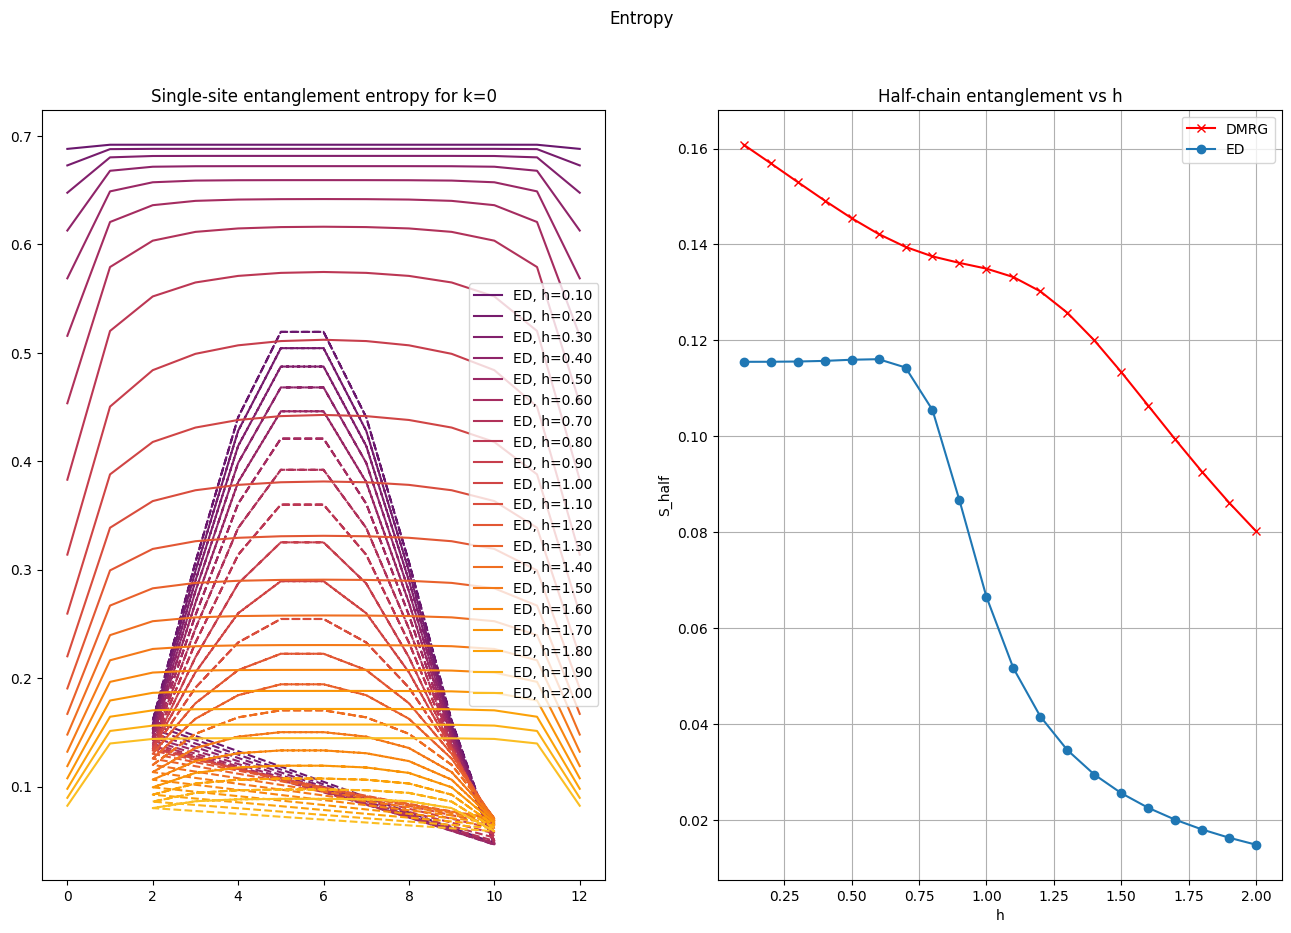

In [7]:
# --- entropy ---
plot_entropy(filename, single_site_entropy_curves, half_chain_entropy, values=values, scan_var=scan_var, opp=opp, set=set)

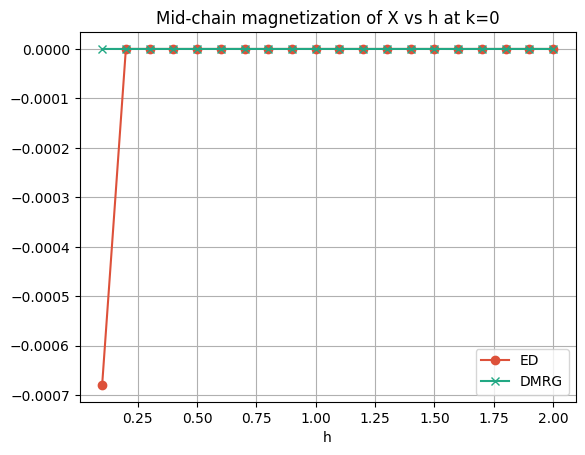

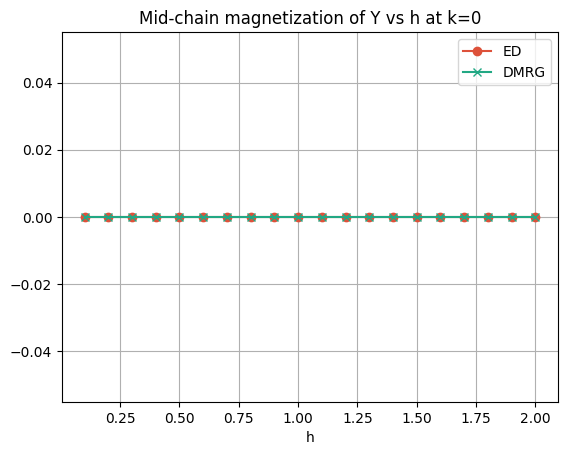

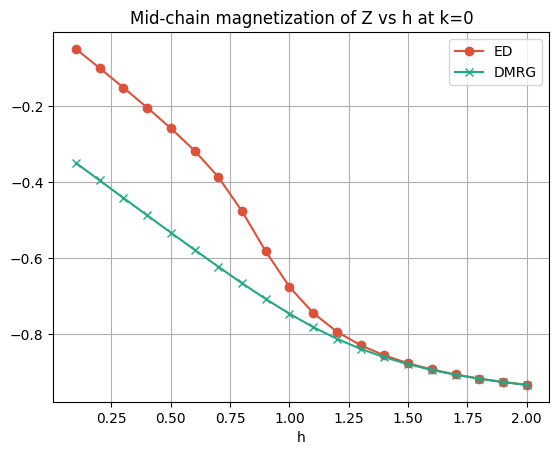

In [11]:
# --- site magnetization ---
plot_site(filename, 'X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)

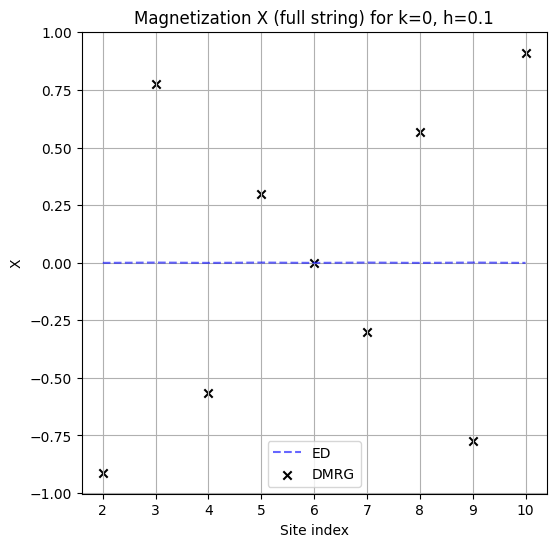

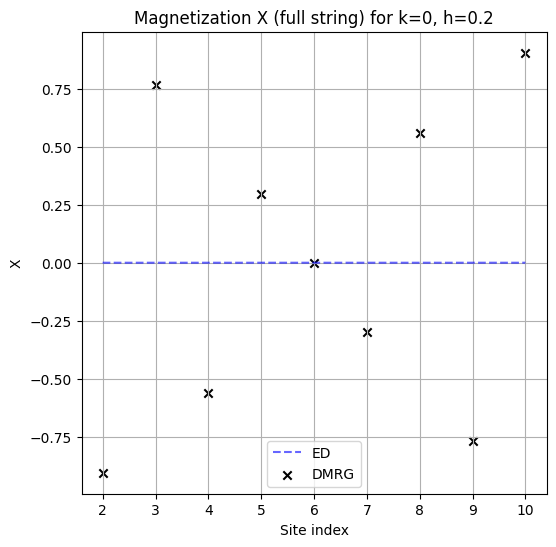

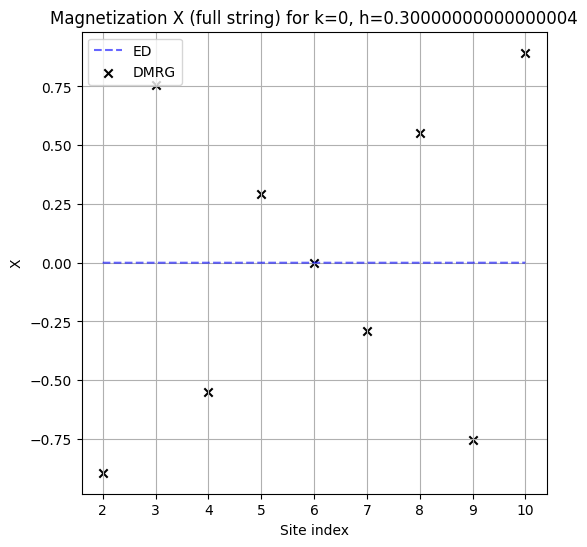

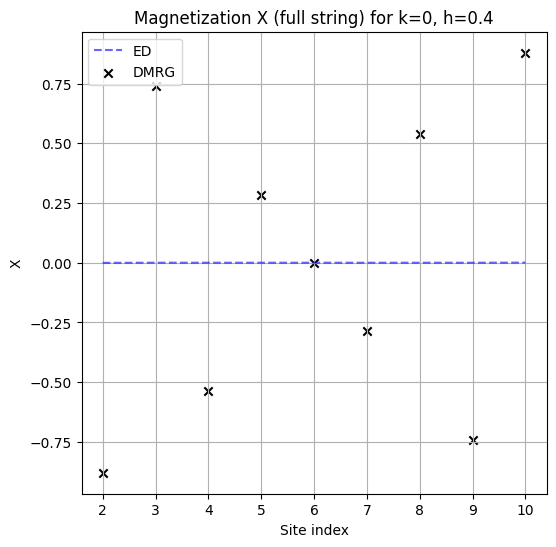

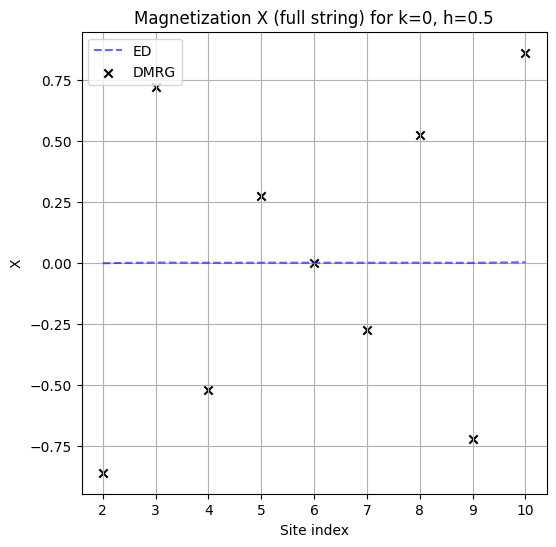

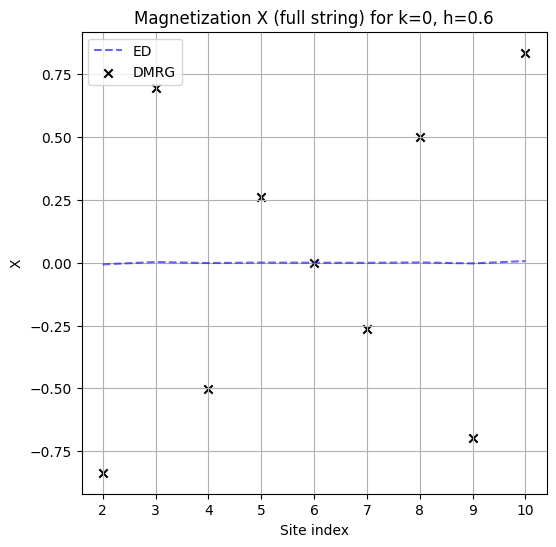

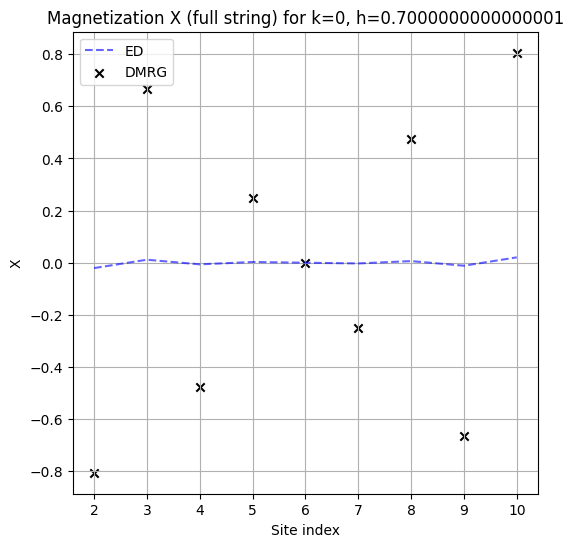

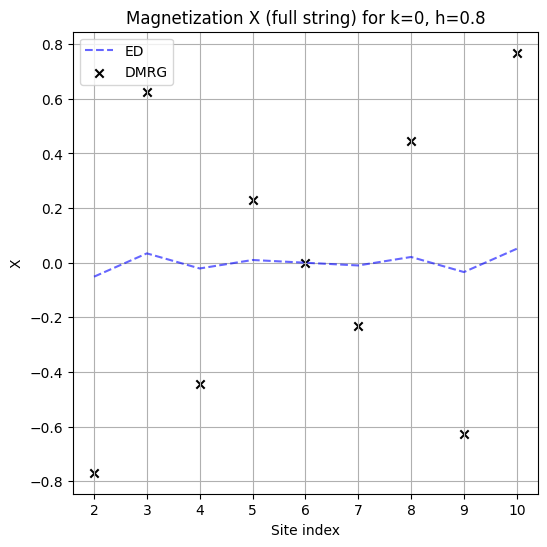

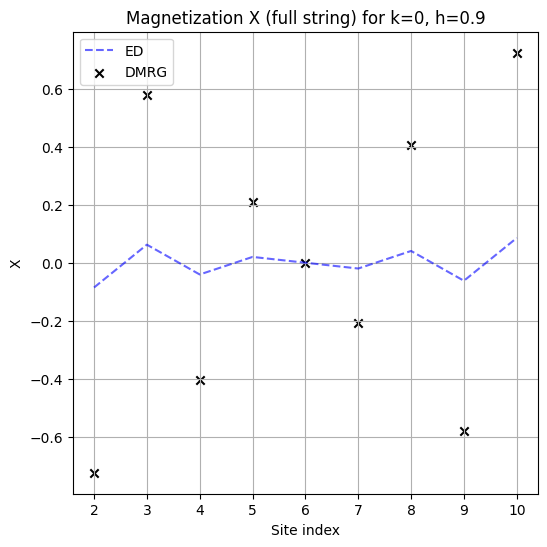

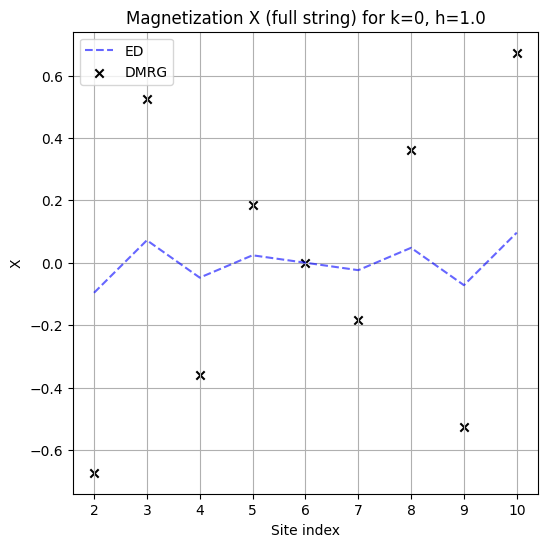

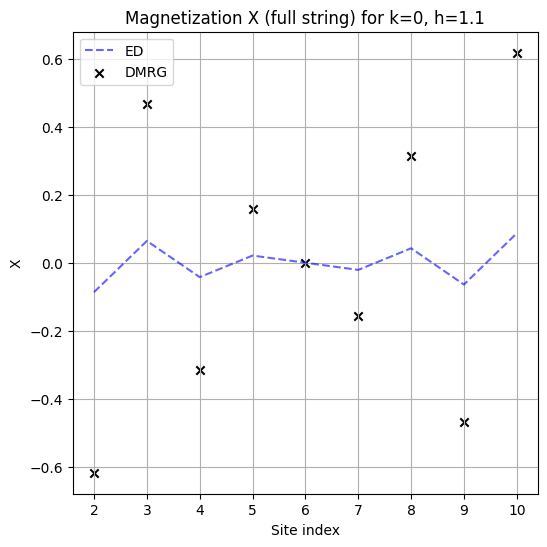

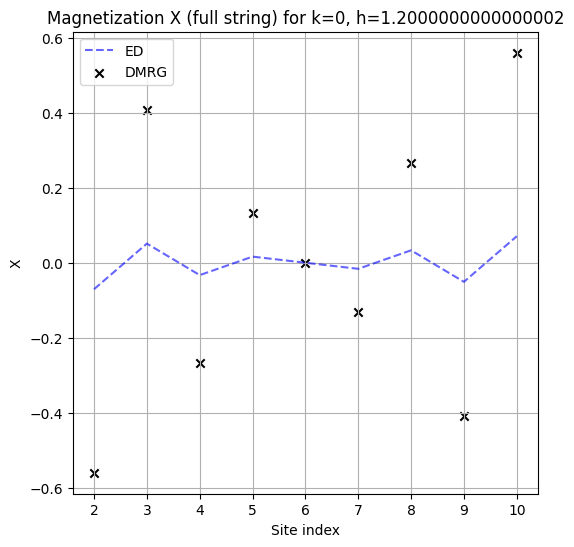

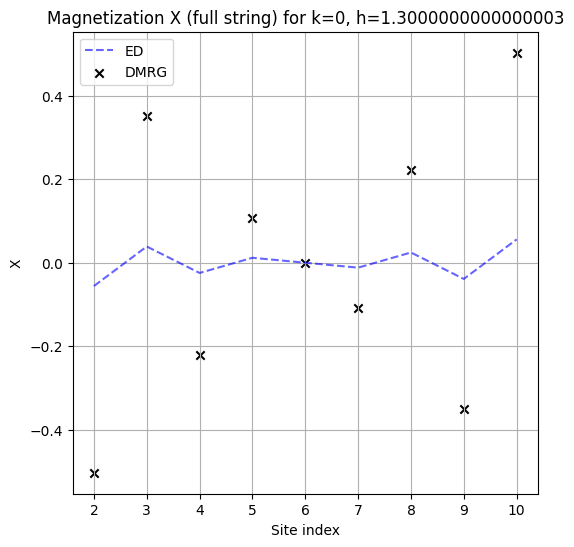

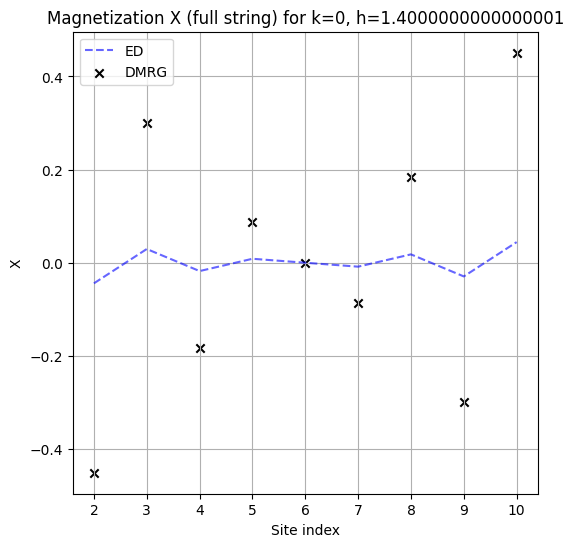

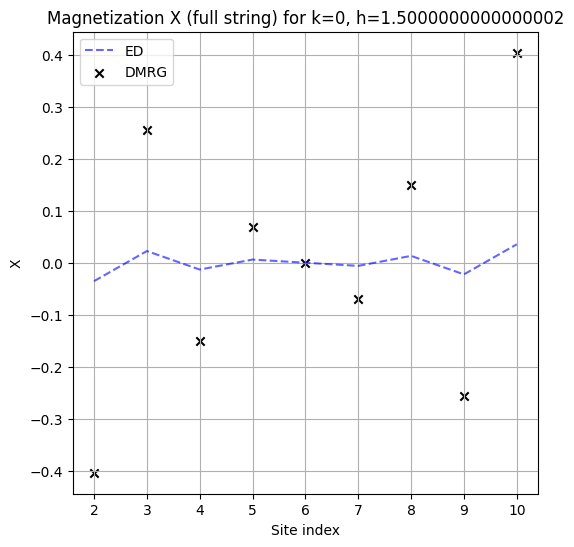

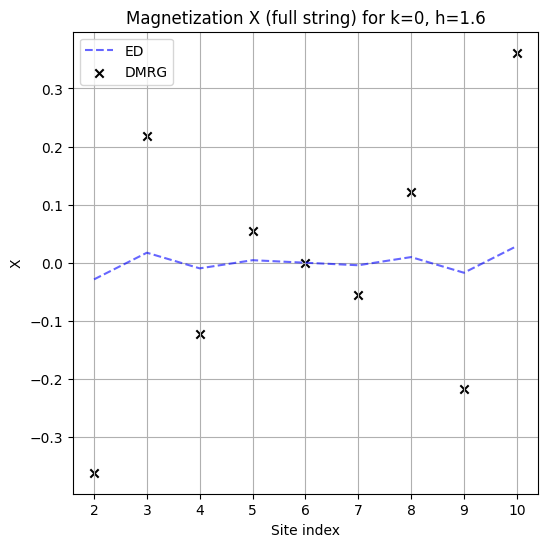

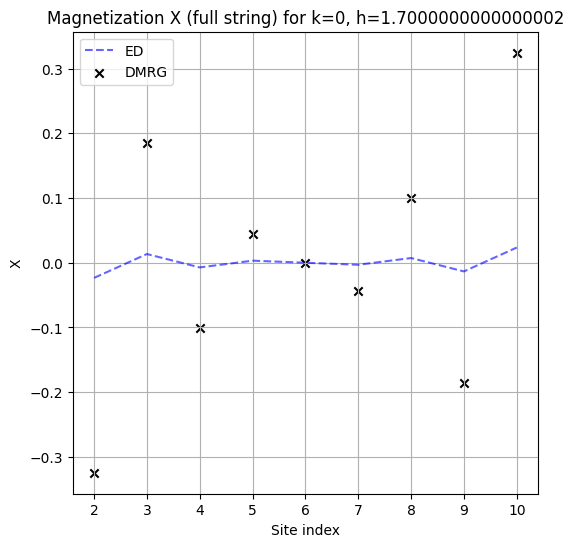

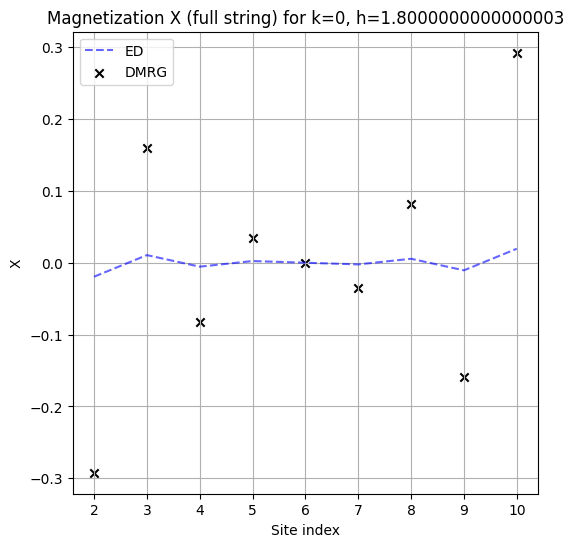

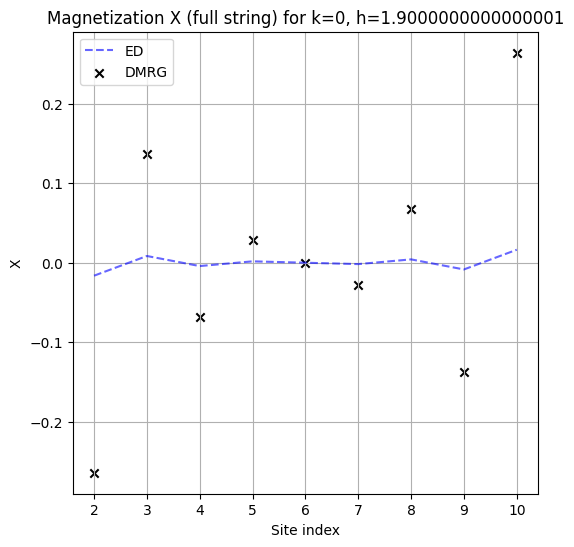

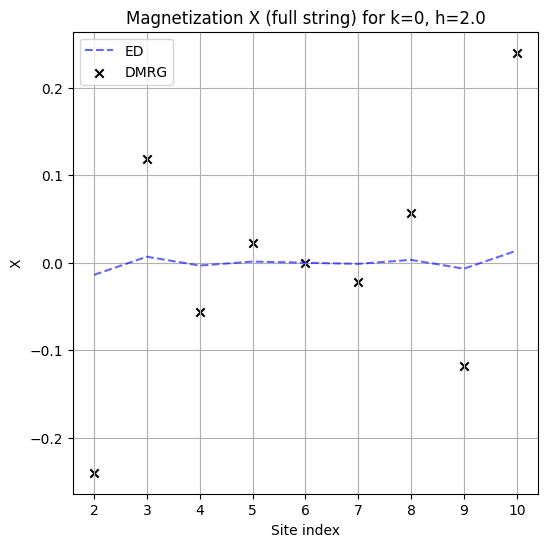

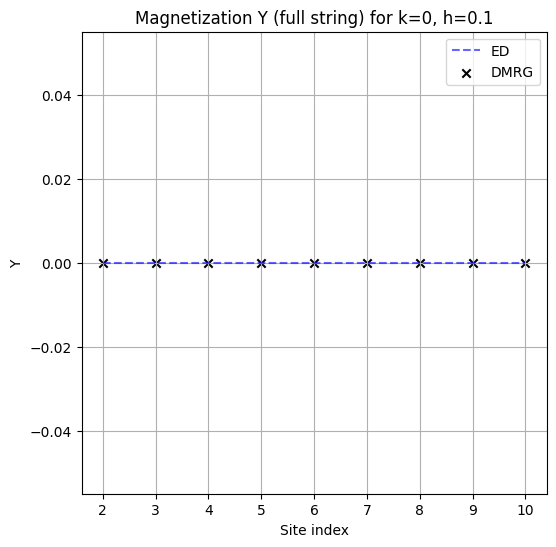

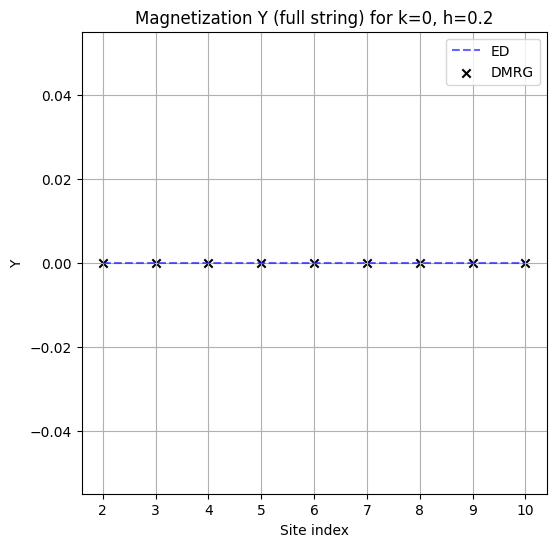

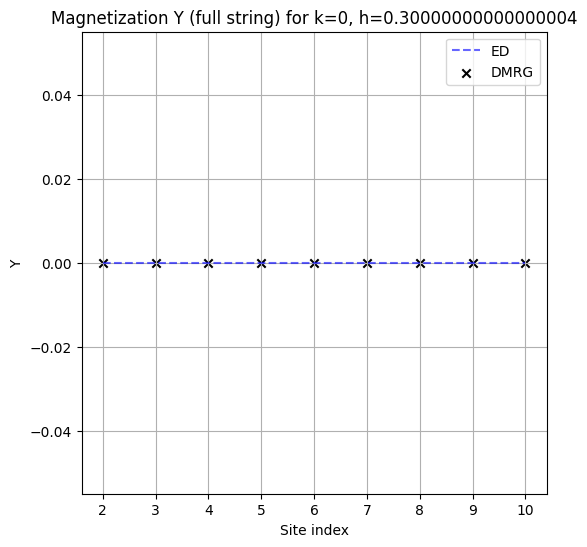

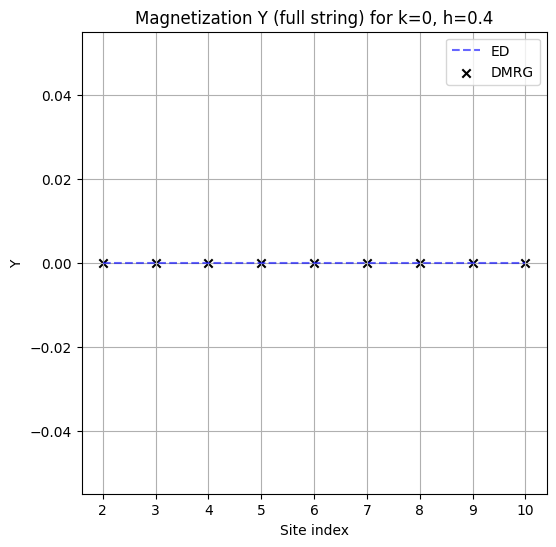

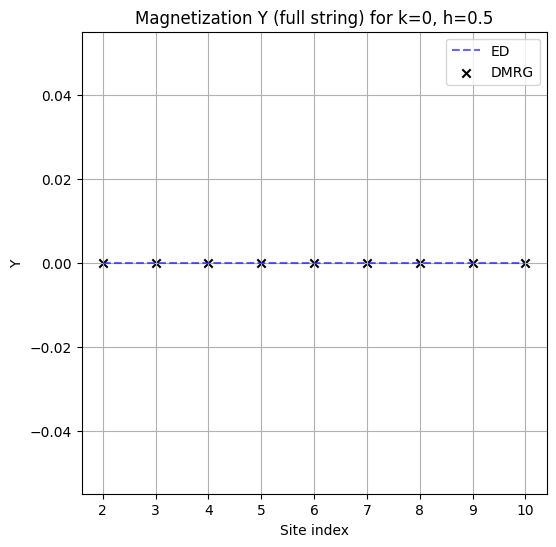

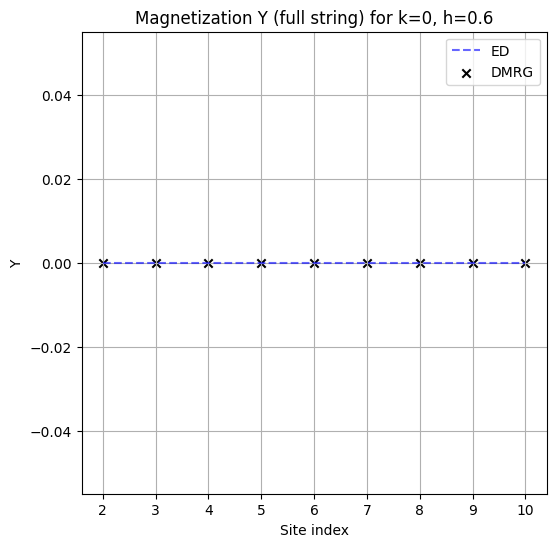

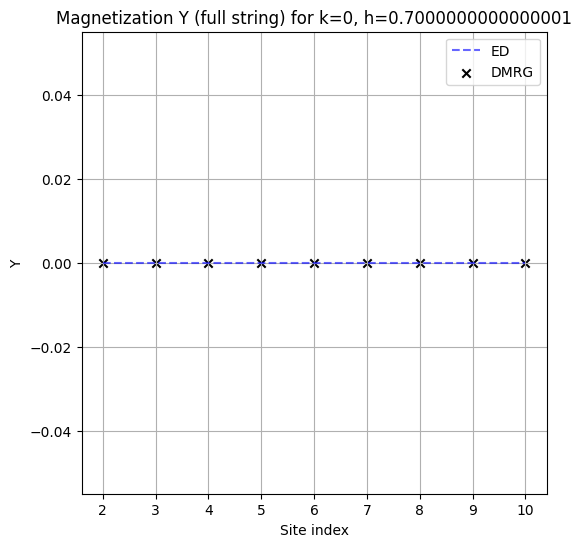

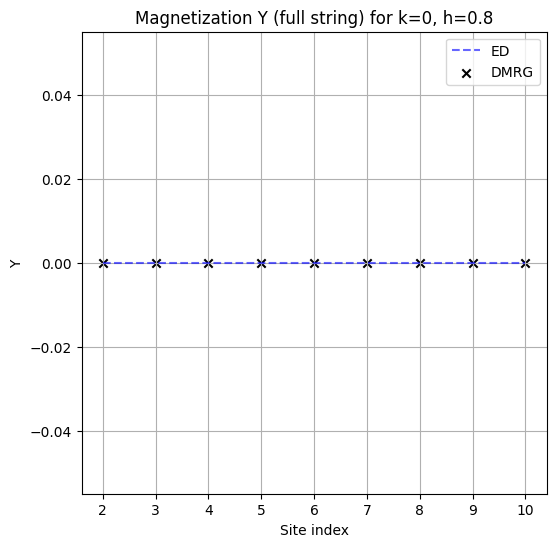

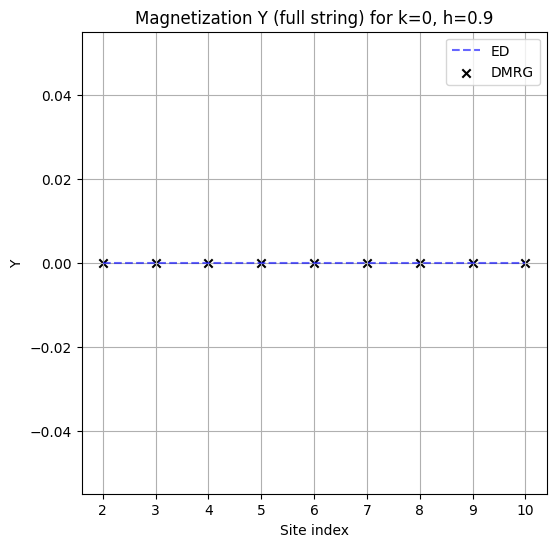

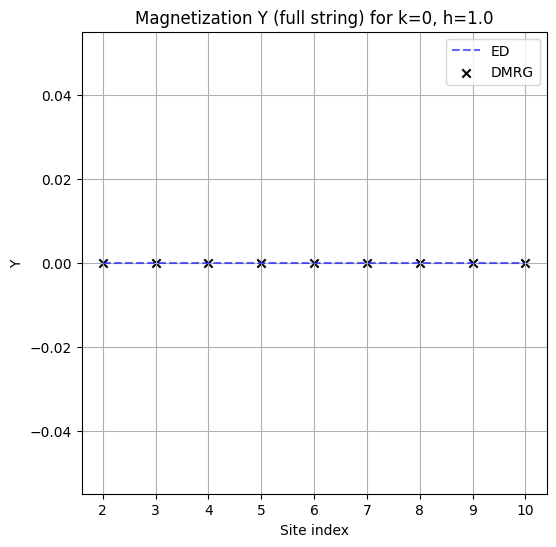

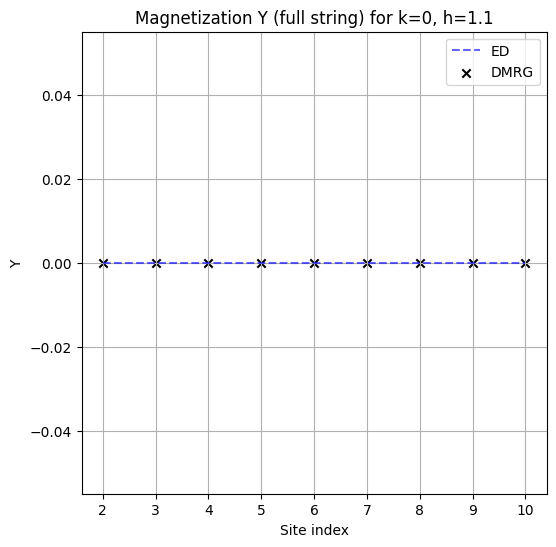

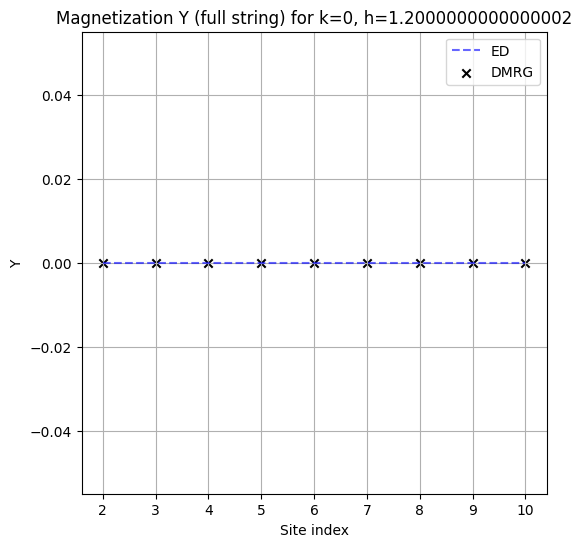

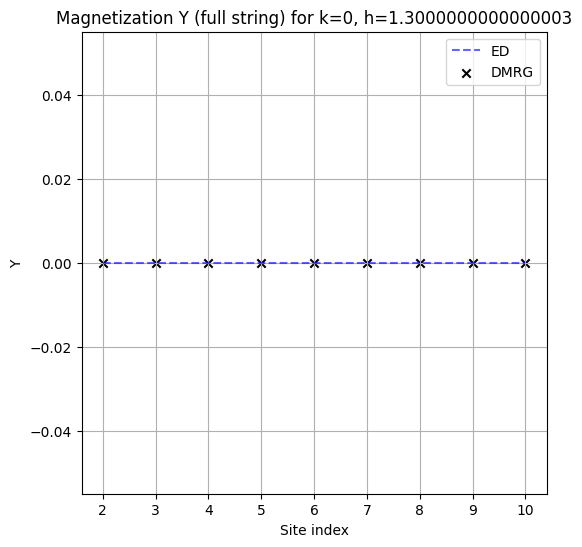

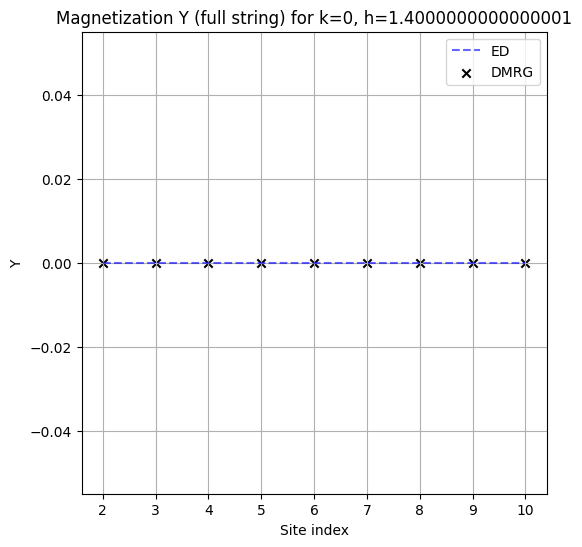

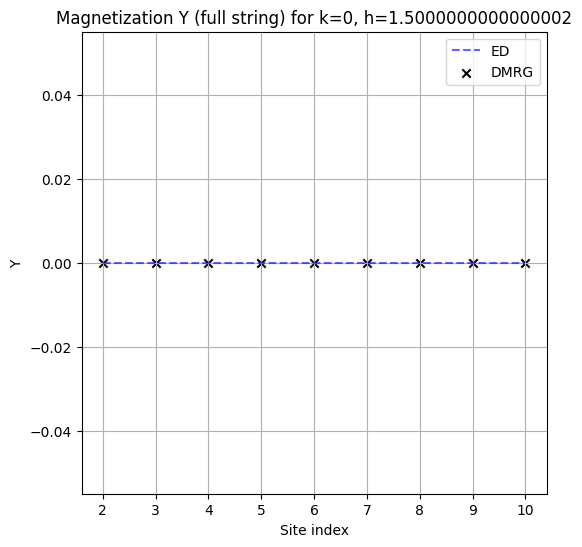

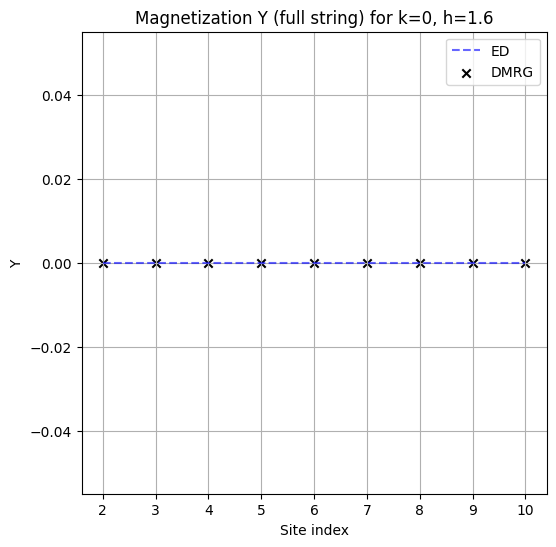

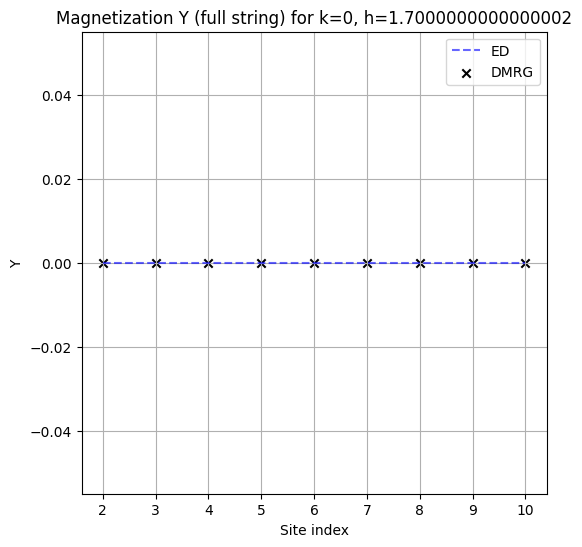

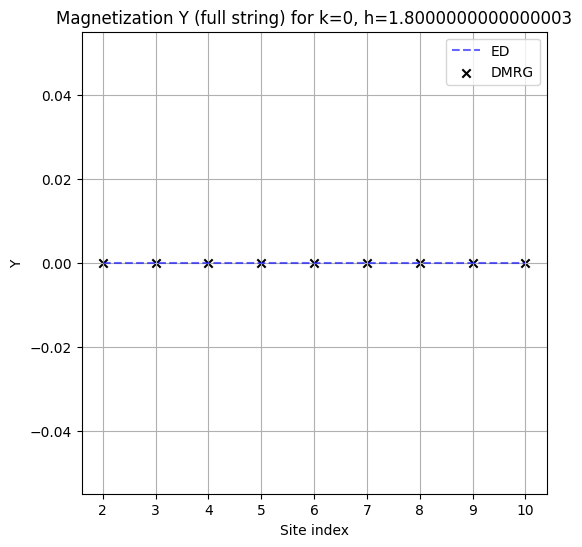

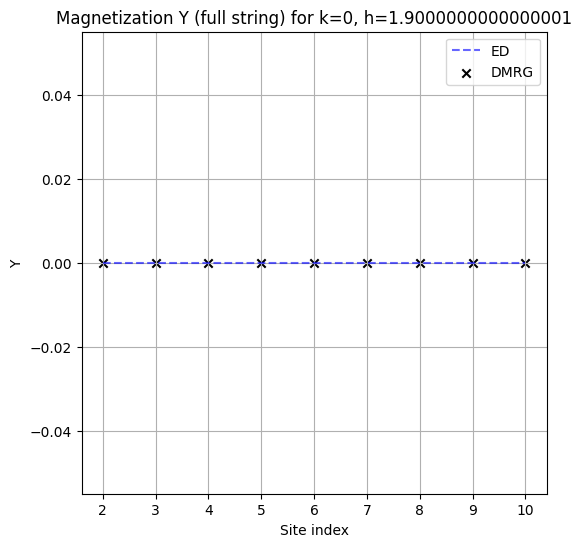

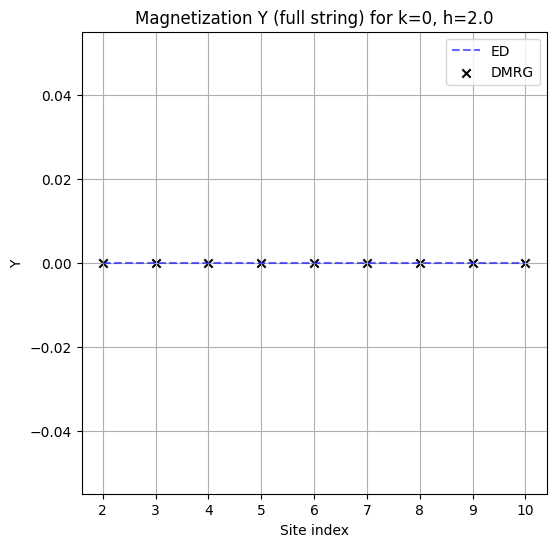

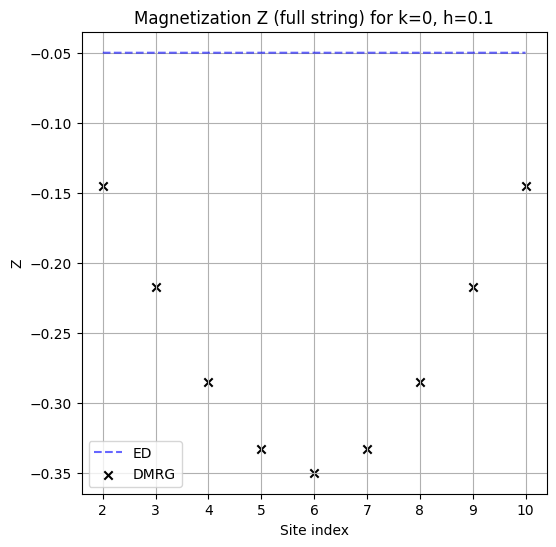

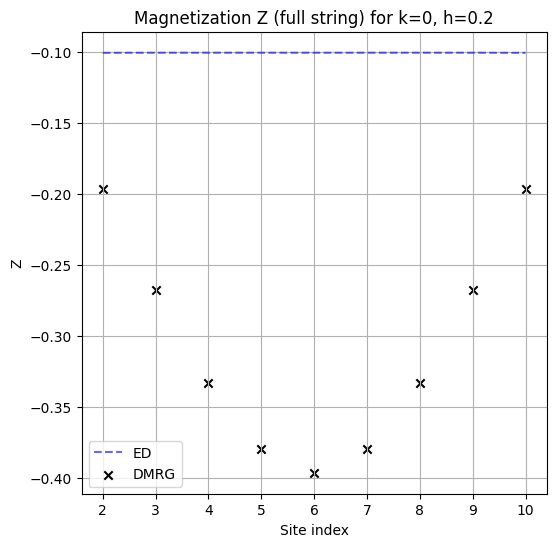

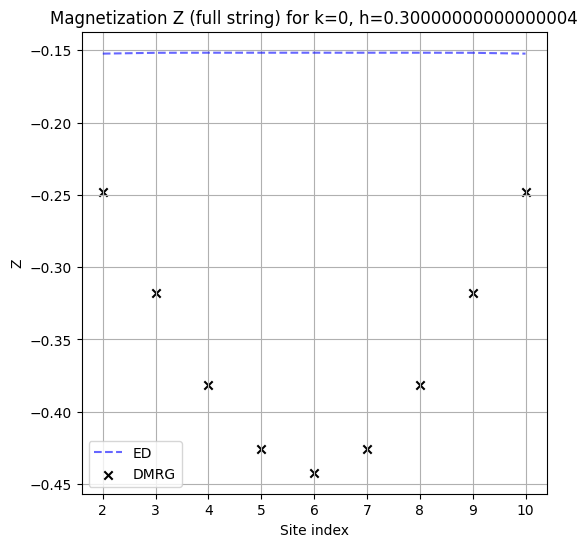

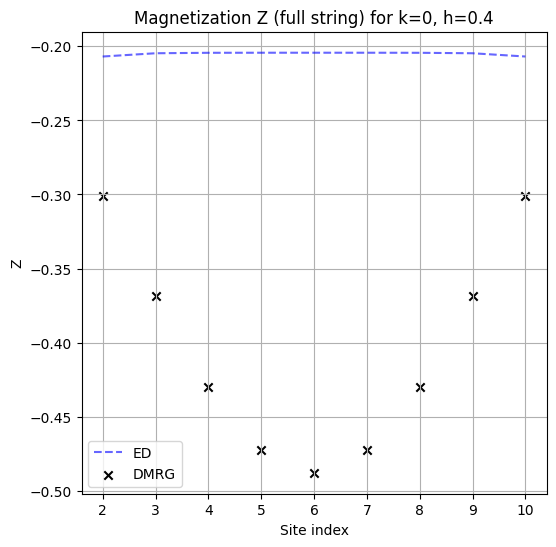

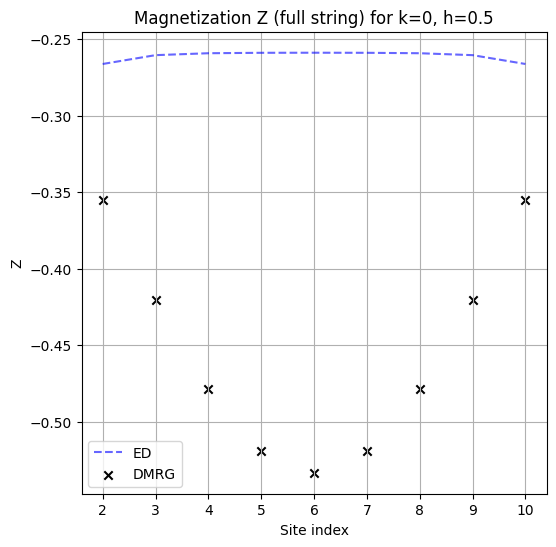

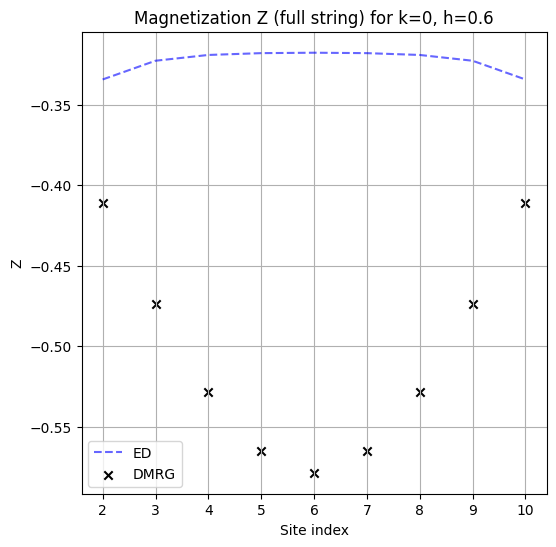

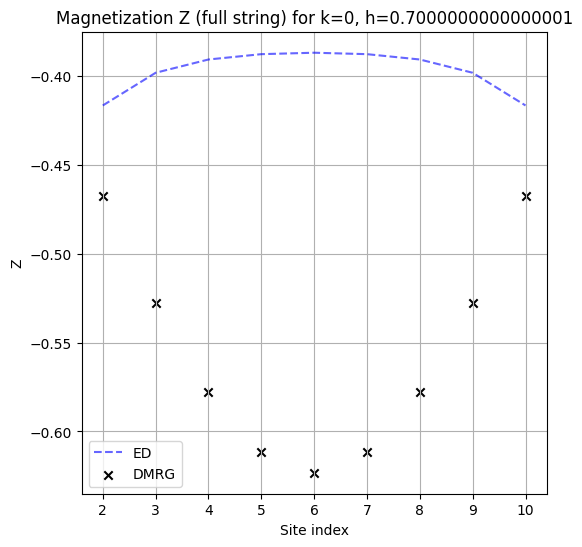

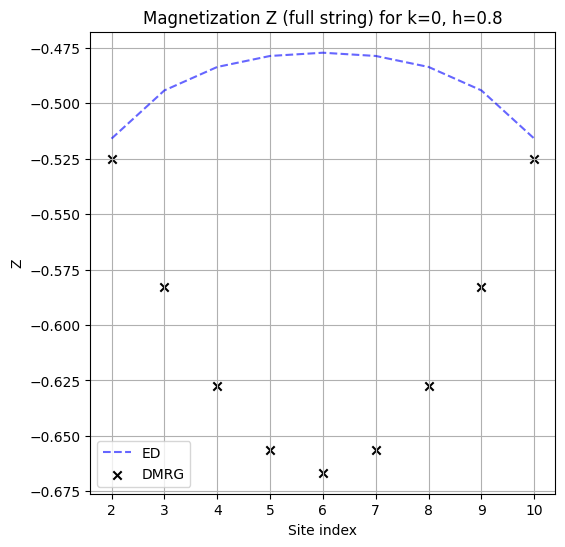

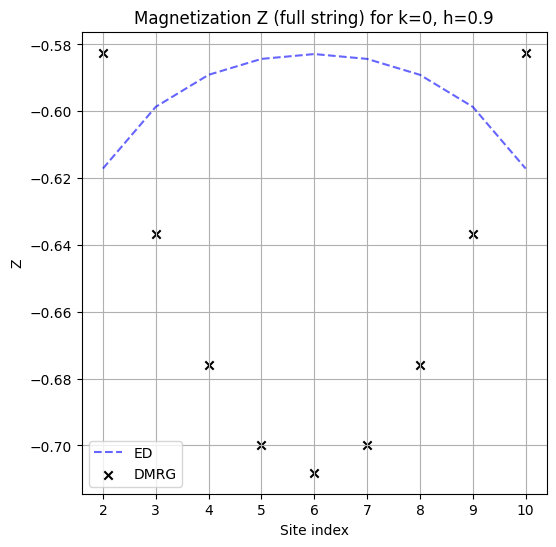

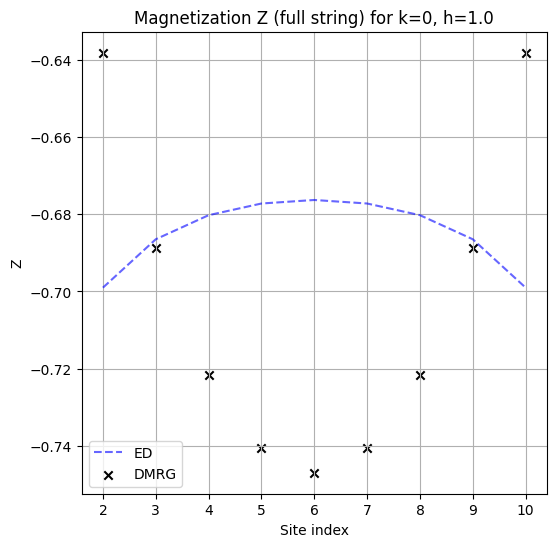

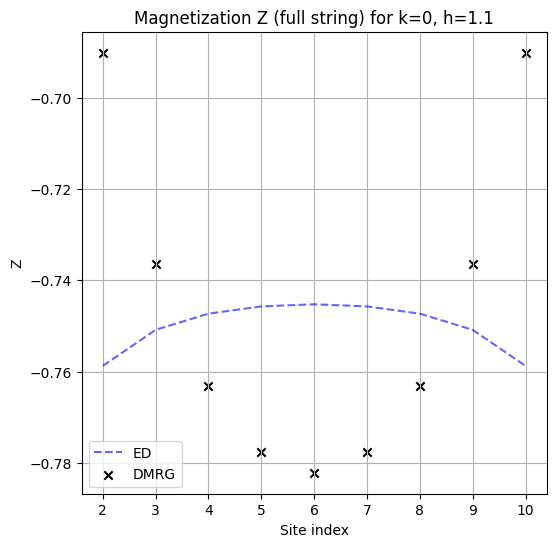

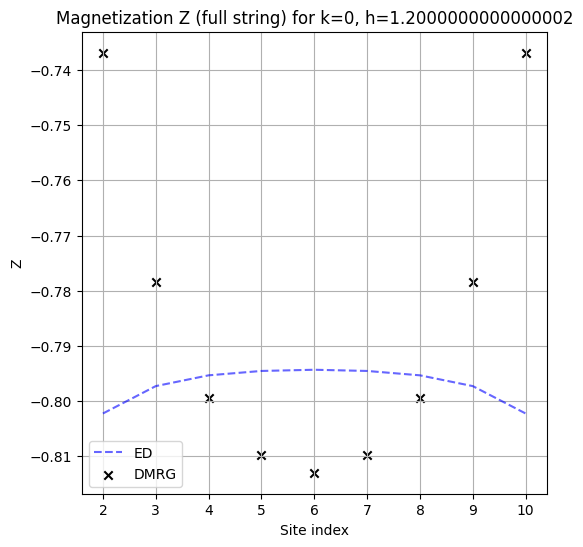

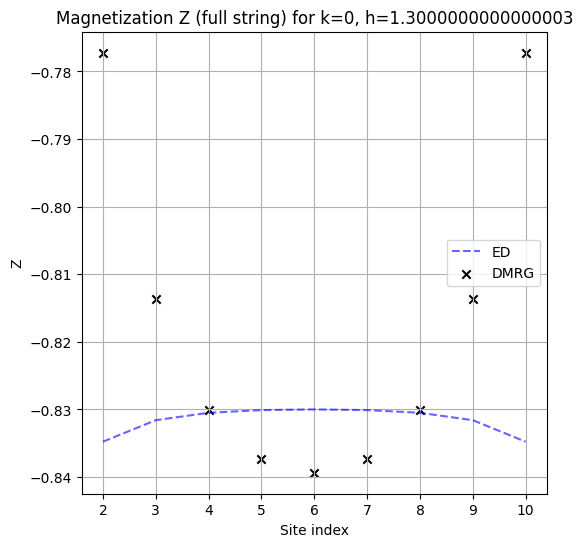

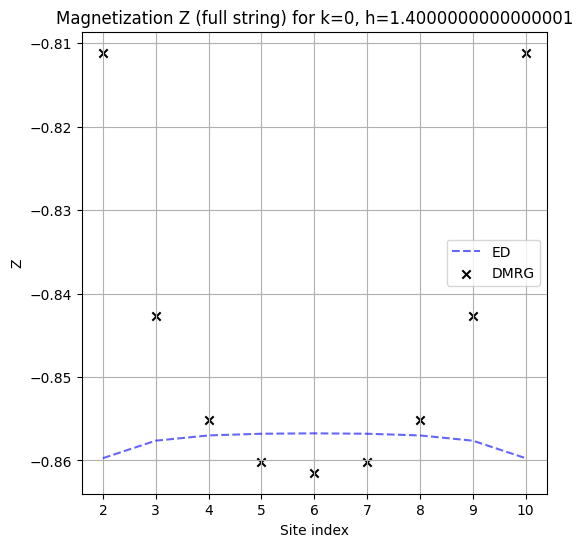

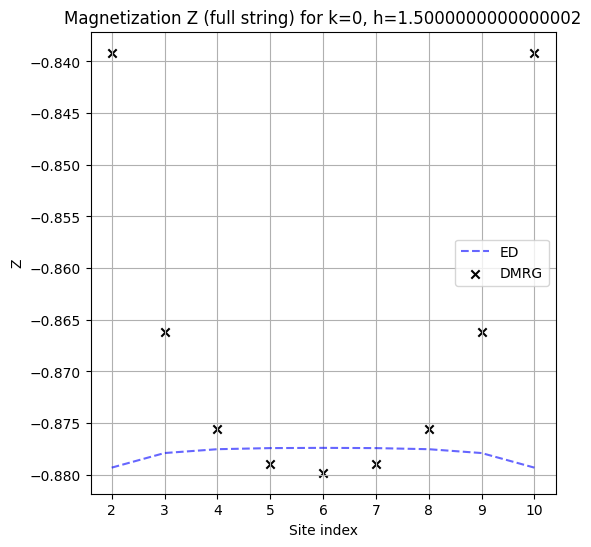

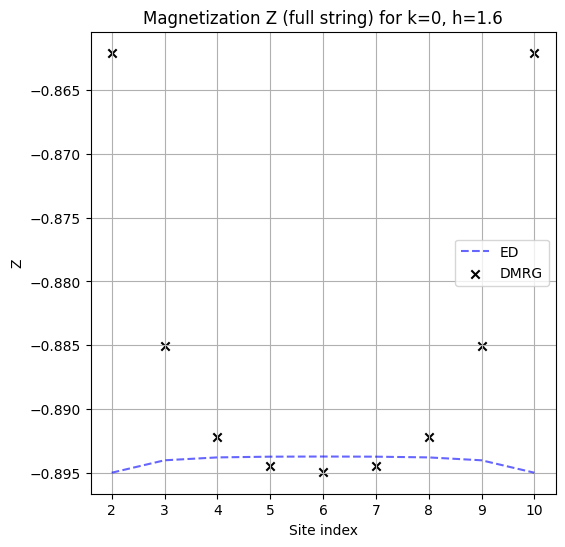

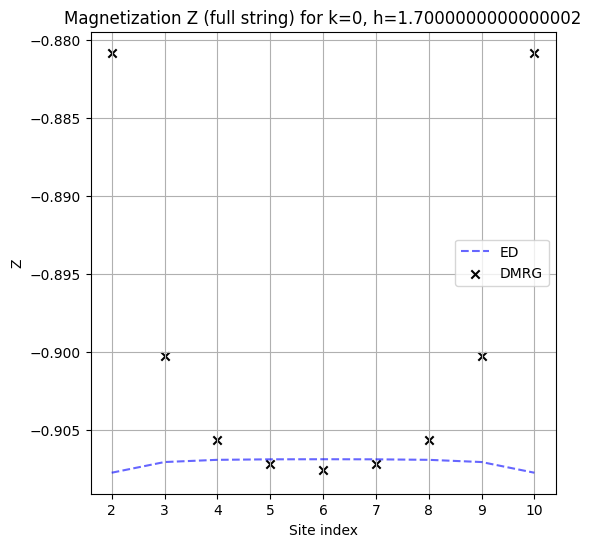

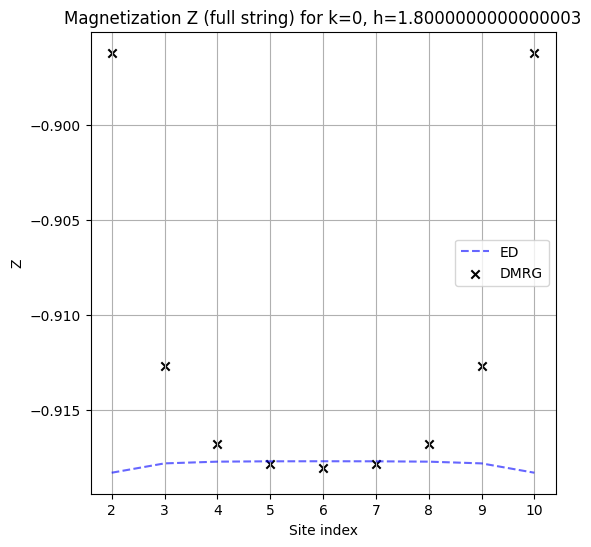

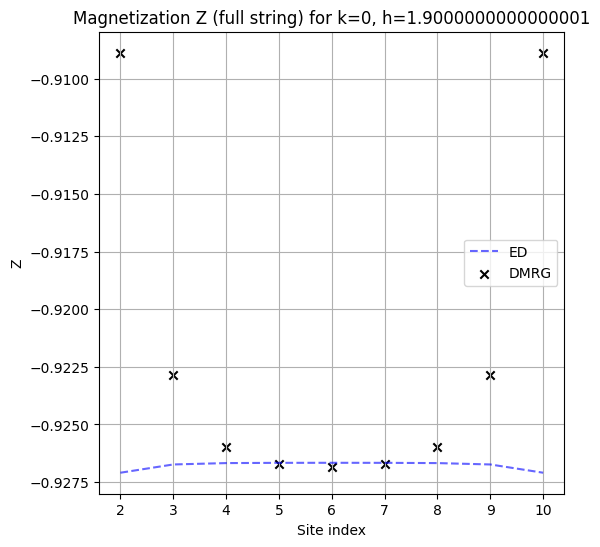

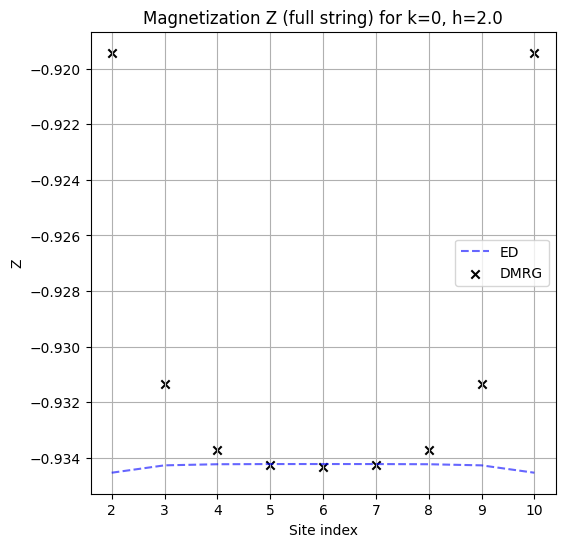

In [13]:
# --- string magnetization ----
plot_string(filename, 'X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ioannisangelotassioulas/Documents/master_thesis/.venv/lib64/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


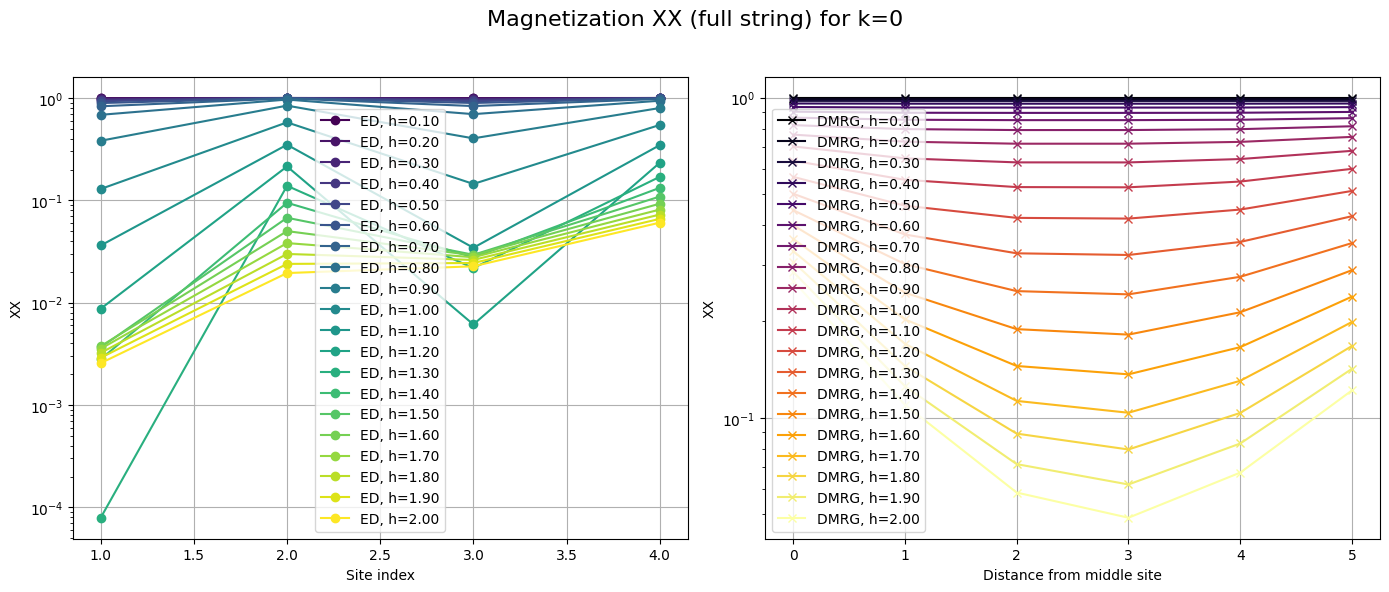

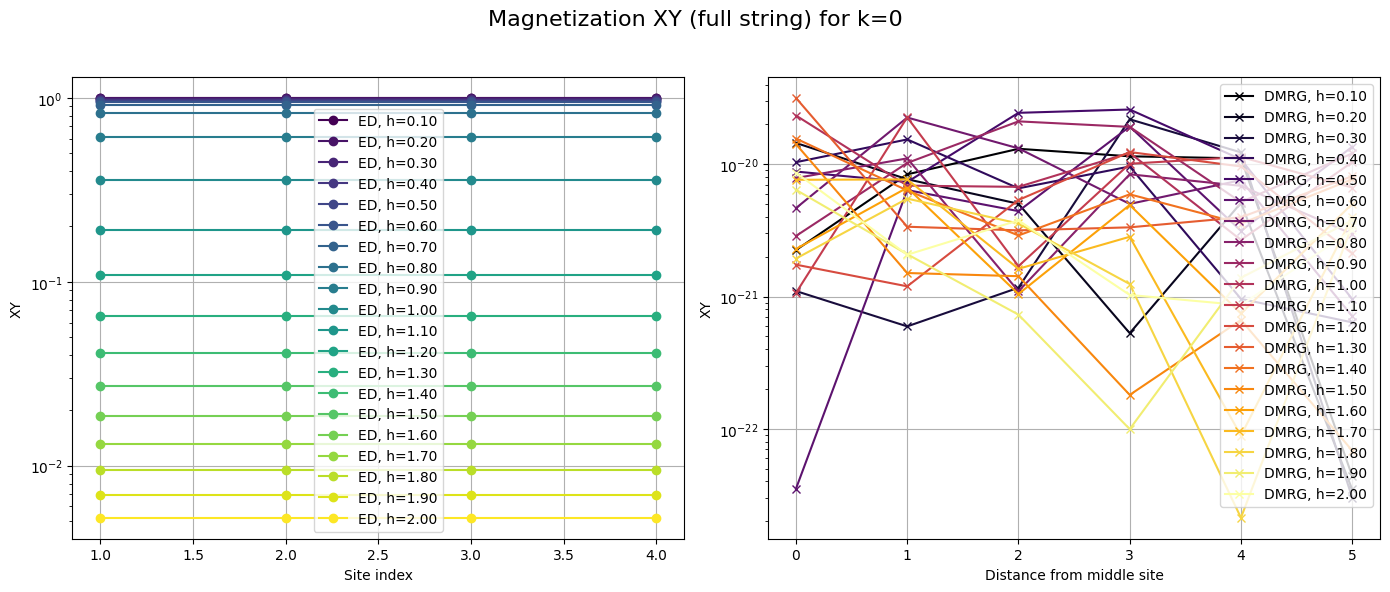

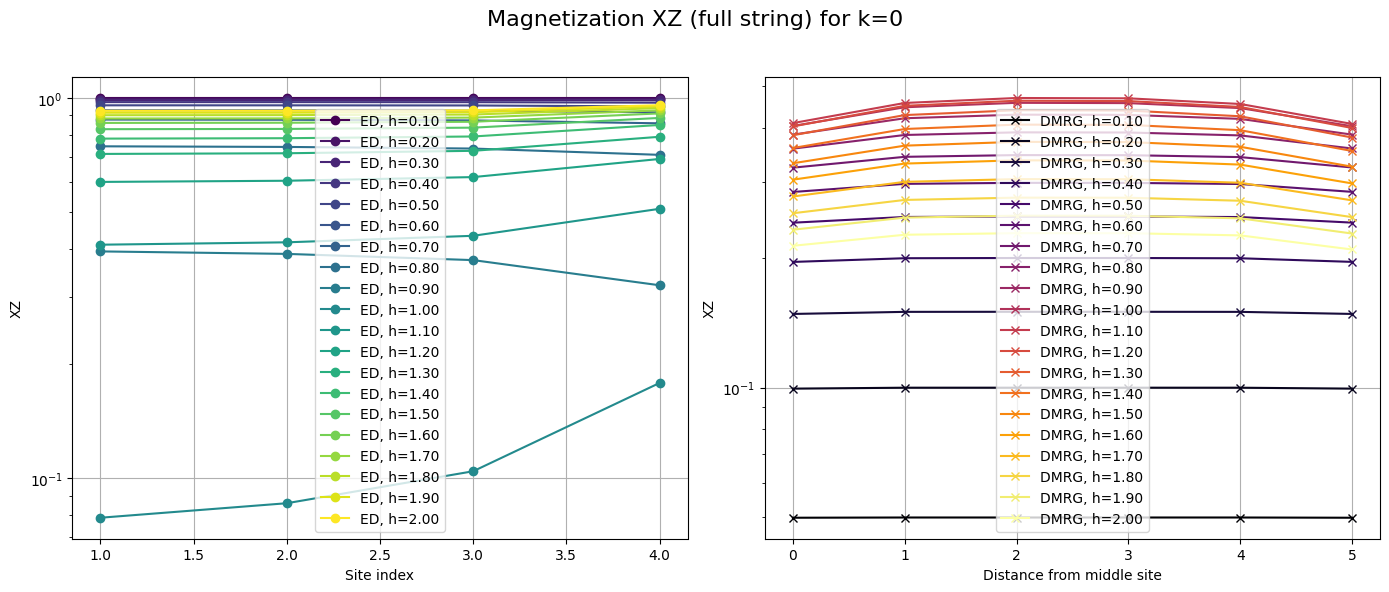

/home/ioannisangelotassioulas/Documents/master_thesis/books/ed_utils.py:307: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle


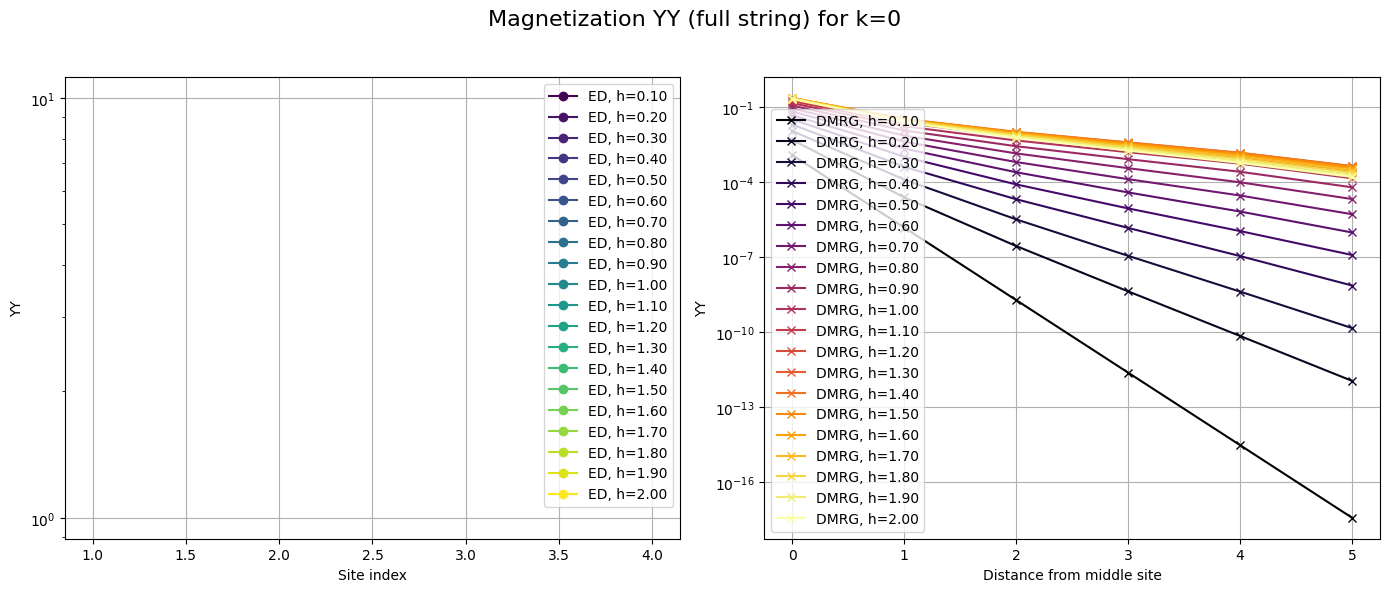

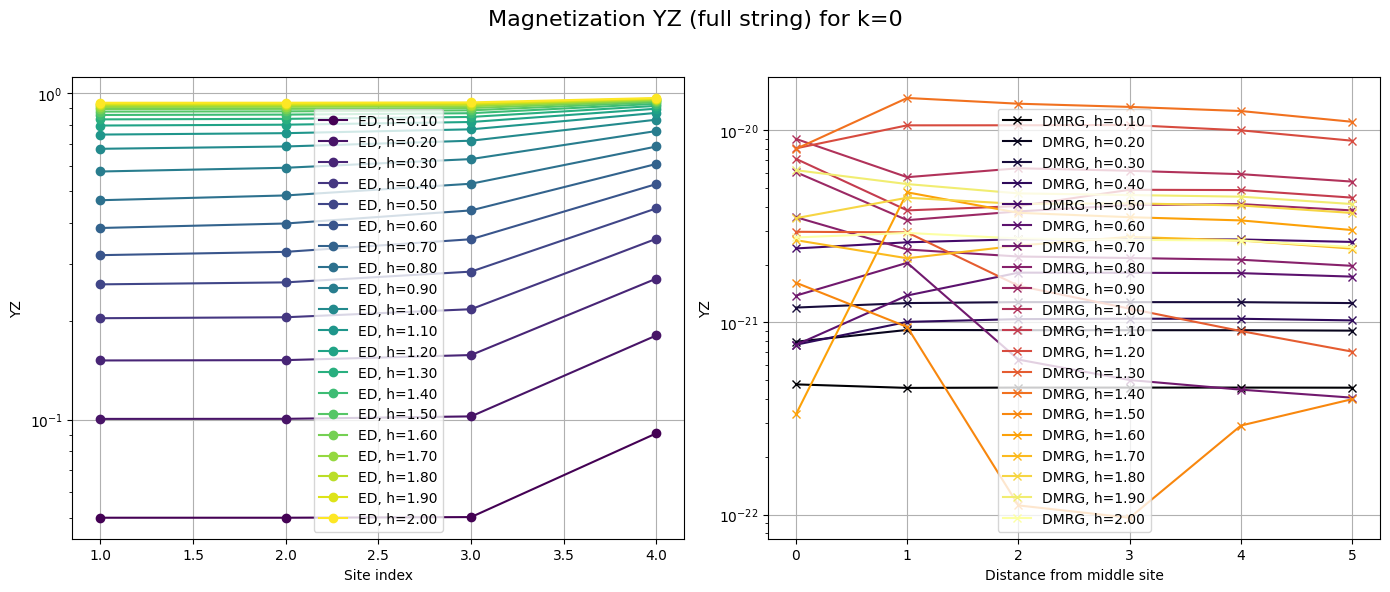

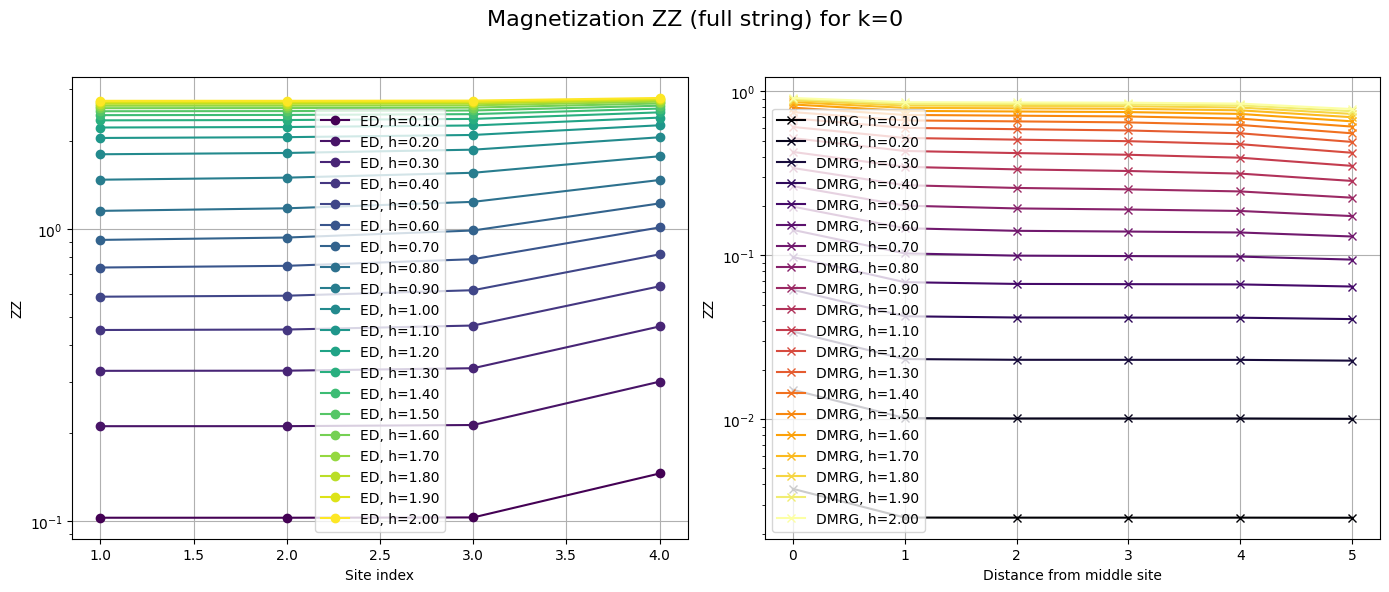

In [5]:
# --- correlations ---
plot_correlator(filename, 'XX', values, xx_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator(filename, 'XY', values, xy_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator(filename, 'XZ', values, xz_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator(filename, 'YY', values, yy_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator(filename, 'YZ', values, yz_corr, scan_var=scan_var, opp=opp, set=set)
plot_correlator(filename, 'ZZ', values, zz_corr, scan_var=scan_var, opp=opp, set=set)